In [3]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scipy

'c:\Users\Sanju Kumavat\OneDrive\Desktop\INTERNSHIP ASSIGNMENT 4\.venv\Scripts\pip.exe' was blocked by your organization's Device Guard policy.
Contact your support person for more info.


In [31]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, zscore

# Set plot style
sns.set(style="whitegrid")

In [32]:
# Load dataset

df = pd.read_csv("Processed_Flipdata - Processed_Flipdata (1).csv")

In [33]:
df.shape

(541, 12)

In [34]:
df.head()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


In [35]:
df = df.drop(columns=["Unnamed: 0"])


In [36]:
df.head()


,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model          541 non-null    str    
 1   Colour         541 non-null    str    
 2   Memory         541 non-null    int64  
 3   RAM            541 non-null    int64  
 4   Battery_       541 non-null    int64  
 5   Rear Camera    541 non-null    str    
 6   Front Camera   541 non-null    str    
 7   AI Lens        541 non-null    int64  
 8   Mobile Height  541 non-null    float64
 9   Processor_     541 non-null    str    
 10  Prize          541 non-null    str    
dtypes: float64(1), int64(4), str(6)
memory usage: 46.6 KB


In [79]:
df.rename(columns={"Battery_":"Battery", "Processor_":"Processor"}, inplace=True)

In [38]:
df["Prize"] = df["Prize"].str.replace(",", "").astype(int)

In [39]:
df["Rear Camera"] = df["Rear Camera"].str.replace("MP","").astype(int)
df["Front Camera"] = df["Front Camera"].str.replace("MP","").astype(int)

In [40]:
df.head()


,Model,Colour,Memory,RAM,Battery,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor,Prize
0,Infinix SMART 7,Night Black,64,4,6000,13,5,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,Infinix SMART 7,Azure Blue,64,4,6000,13,5,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,MOTOROLA G32,Mineral Gray,128,8,5000,50,16,0,16.64,Qualcomm Snapdragon 680,11999
3,POCO C50,Royal Blue,32,2,5000,8,5,0,16.56,Mediatek Helio A22,5649
4,Infinix HOT 30i,Marigold,128,8,5000,50,5,1,16.76,G37,8999


In [41]:
df.describe(include="all")

,Model,Colour,Memory,RAM,Battery,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor,Prize
count,541,541,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541,541.000000
unique,187,275,NaN,NaN,NaN,NaN,NaN,NaN,NaN,123,NaN
top,realme C55,Yellow,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Qualcomm Snapdragon 680,NaN
freq,9,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33,NaN
mean,NaN,NaN,110.550832,5.397412,4871.587800,46.110906,11.992606,0.062847,16.431201,NaN,16228.375231
std,NaN,NaN,60.600694,1.984923,780.148862,31.260416,9.053746,0.242911,2.523553,NaN,10793.588322
min,NaN,NaN,16.000000,2.000000,800.000000,0.000000,0.000000,0.000000,4.500000,NaN,920.000000
25%,NaN,NaN,64.000000,4.000000,5000.000000,13.000000,5.000000,0.000000,16.510000,NaN,9290.000000
50%,NaN,NaN,128.000000,6.000000,5000.000000,50.000000,8.000000,0.000000,16.710000,NaN,13499.000000
75%,NaN,NaN,128.000000,8.000000,5000.000000,50.000000,16.000000,0.000000,16.940000,NaN,19280.000000


In [42]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 10


In [43]:
# Show duplicate rows only
duplicates = df[df.duplicated()]
print(duplicates)



                     Model          Colour  Memory  RAM  Battery  Rear Camera  \
27             vivo T2x 5G     Marine Blue     128    6     5000           50   
48            MOTOROLA e32     Arctic Blue      64    4     5000           50   
91   SAMSUNG Galaxy F14 5G   B.A.E. Purple     128    4     6000           50   
132  SAMSUNG Galaxy F14 5G       OMG Black     128    6     6000           50   
247              redmi min             M3)      16    4     1000            0   
344         Tecno Spark 9T  Turquoise Cyan      64    4     5000           50   
352         POCO X4 Pro 5G     Laser Black     128    8     5000           64   
424            realme C30s    Stripe Black      64    4     5000            8   
437           vivo Y100 5G    Pacific Blue     128    8     4500           64   
480               POCO C31      Royal Blue      64    4     5000           13   

     Front Camera  AI Lens  Mobile Height                        Processor  \
27              8        0    

In [44]:
# Show duplicates including originals
duplicates_full = df[df.duplicated(keep=False)]
print(duplicates_full)

                     Model          Colour  Memory  RAM  Battery  Rear Camera  \
23             vivo T2x 5G     Marine Blue     128    6     5000           50   
27             vivo T2x 5G     Marine Blue     128    6     5000           50   
46            MOTOROLA e32     Arctic Blue      64    4     5000           50   
48            MOTOROLA e32     Arctic Blue      64    4     5000           50   
90   SAMSUNG Galaxy F14 5G   B.A.E. Purple     128    4     6000           50   
91   SAMSUNG Galaxy F14 5G   B.A.E. Purple     128    4     6000           50   
130  SAMSUNG Galaxy F14 5G       OMG Black     128    6     6000           50   
132  SAMSUNG Galaxy F14 5G       OMG Black     128    6     6000           50   
246              redmi min             M3)      16    4     1000            0   
247              redmi min             M3)      16    4     1000            0   
332         Tecno Spark 9T  Turquoise Cyan      64    4     5000           50   
344         Tecno Spark 9T  

### Insight on Duplicate Check

During the duplicate check in Python using `df.duplicated().sum()`, the dataset flagged **10 duplicate rows**.  
However, when verifying in Excel by selecting all data and checking for duplicates, **no duplicate values were detected**.  

This difference occurs because:
- **Pandas** considers a row duplicate only if *all column values* match another row exactly.  
- **Excel** checks duplicates based on selected columns, and since the dataset has no single unique identifier column, Excel did not flag them.  

📌 **Decision:** Since duplicates may represent valid listings and Excel did not confirm them, the dataset will be **retained as-is without removing any rows**.


## Univariate Analysis (Numerical)


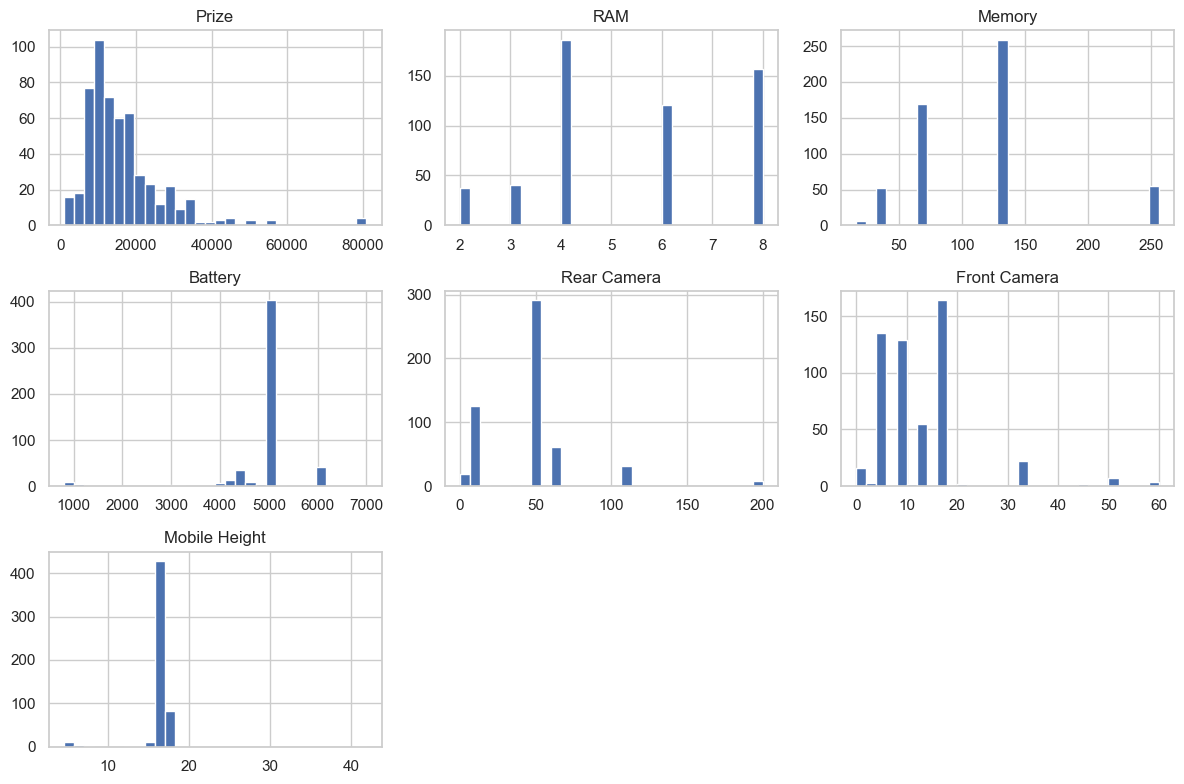

In [45]:
# Histograms for numerical features

num_cols = ['Prize', 'RAM', 'Memory', 'Battery', 'Rear Camera', 'Front Camera', 'Mobile Height']
df[num_cols].hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()

### Insight from Histograms

The distribution of numerical features reveals clear patterns in the dataset:

- **Prize**: Most smartphones are priced below ₹30,000, with a few high-end models creating a long right tail.  
- **RAM**: Distinct peaks at 4 GB, 6 GB, and 8 GB indicate common configurations in the market.  
- **Memory**: Concentrated around 64 GB and 128 GB, showing these are the most popular storage options.  
- **Battery**: Strong clustering around 5000 mAh, suggesting this is the standard capacity across devices.  
- **Mobile Height**: Majority of phones fall between 15–20 cm, though one extreme outlier (~41 cm) suggests a possible data entry error.

📌 **Decision:** The dataset shows meaningful clusters and standard specifications across devices. Outliers (e.g., very high mobile height) should be flagged for review, but overall the data distributions align with expected smartphone market trends.

## Skewness & Kurtosis

In [46]:

for col in num_cols:
    print(f"{col}: Skewness={df[col].skew():.2f}, Kurtosis={df[col].kurt():.2f}")


Prize: Skewness=2.43, Kurtosis=9.61
RAM: Skewness=0.07, Kurtosis=-1.31
Memory: Skewness=1.03, Kurtosis=0.86
Battery: Skewness=-3.30, Kurtosis=14.75
Rear Camera: Skewness=1.80, Kurtosis=7.23
Front Camera: Skewness=2.49, Kurtosis=8.76
Mobile Height: Skewness=1.17, Kurtosis=48.22


### Insight from Boxplots

Boxplots confirm skewness and kurtosis findings:
- **Prize**: Skewed by a few high-priced models.  
- **RAM & Memory**: Stable clusters, no major anomalies.  
- **Battery**: Outliers (e.g., 800 mAh) distort distribution.  
- **Rear & Front Camera**: Concentrated around common values, but unusual entries (0MP) appear.  
- **Mobile Height**: Extreme outlier (~41 cm) heavily distorts distribution.

📌 **Decision:** Outliers in Battery and Mobile Height should be flagged and treated carefully. Prize may need transformation for modeling, while RAM and Memory are well-behaved.

##  Bivariate Analysis


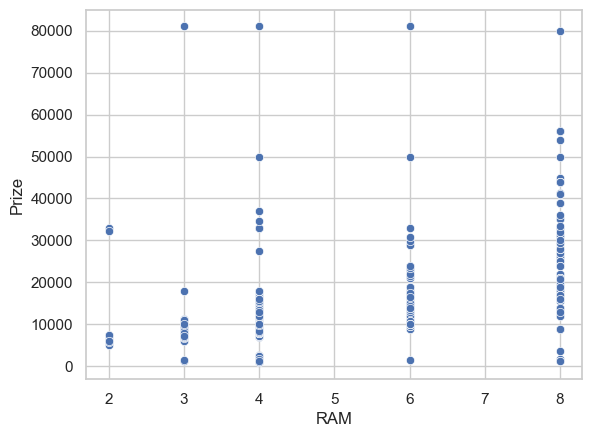

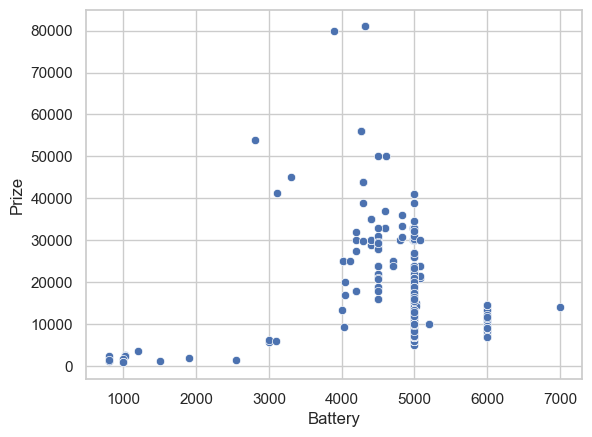

In [48]:
# Scatter plots: Price vs key features
sns.scatterplot(x='RAM', y='Prize', data=df)
plt.show()

sns.scatterplot(x='Battery', y='Prize', data=df)
plt.show()


### Insight from Scatter Plots

- **Prize vs RAM**: Prices generally increase with higher RAM capacities. Clear clusters are visible at 4 GB, 6 GB, and 8 GB, reflecting common market configurations.  
- **Prize vs Battery**: No strong linear relationship is observed. Most devices cluster around 5000 mAh regardless of price, though a few high-capacity batteries (6000–7000 mAh) appear in mid-range models.  

📌 **Decision:** RAM shows a stronger correlation with price compared to battery capacity. Battery size appears standardized across price ranges, while RAM is a clearer differentiator in smartphone pricing.

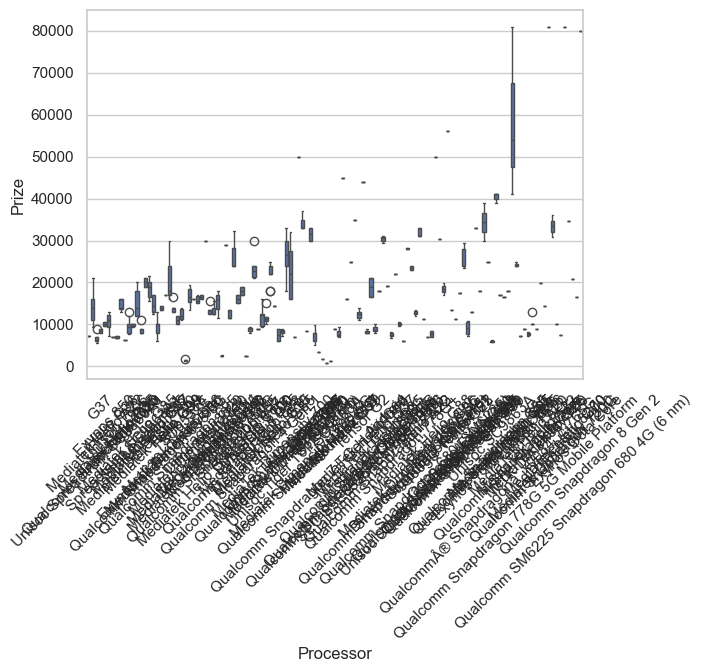

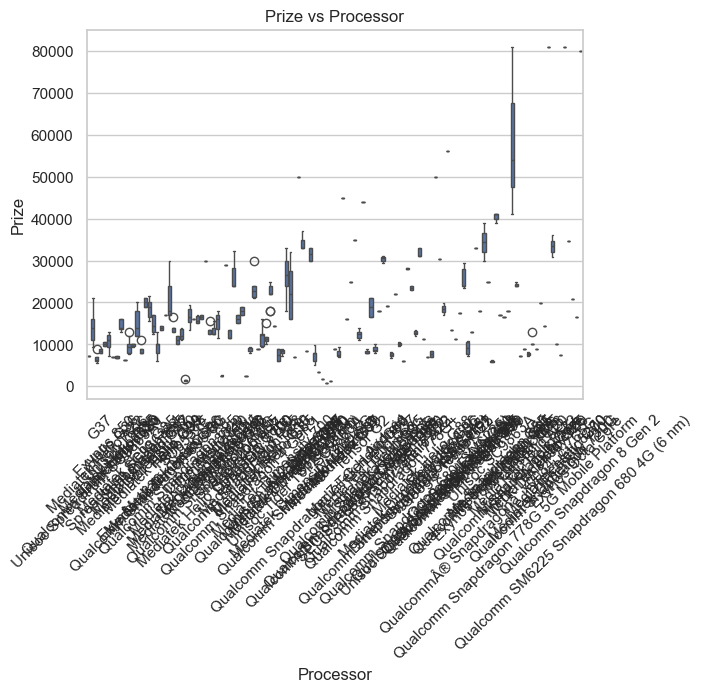

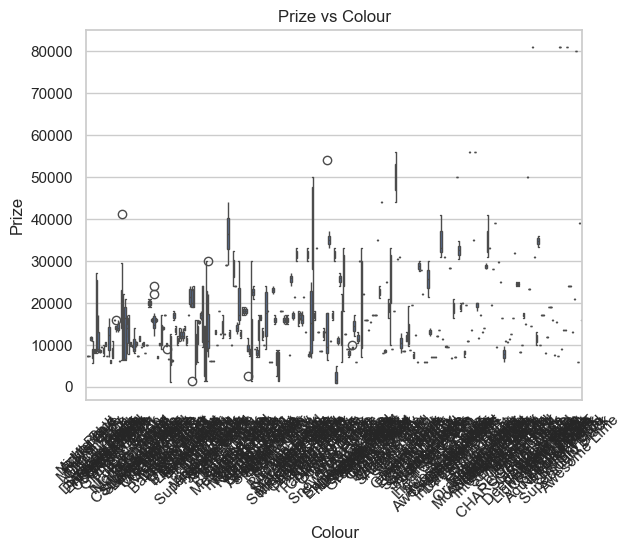

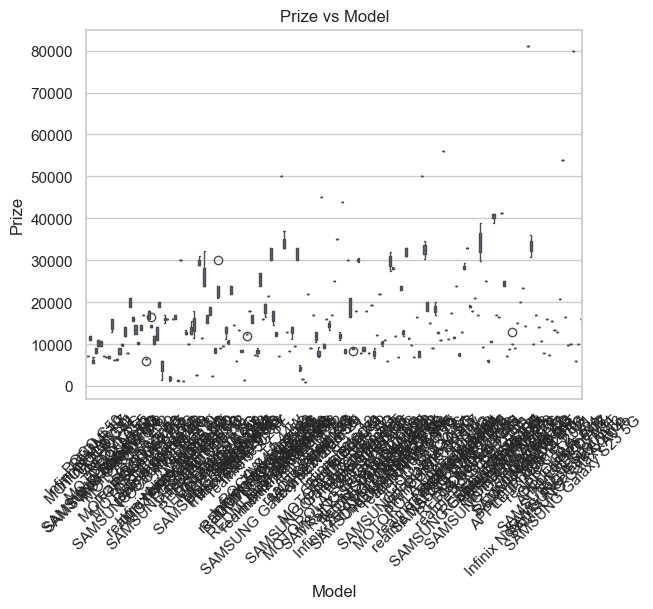

In [53]:
# Boxplot for categorical features
sns.boxplot(x='Processor', y='Prize', data=df)
plt.xticks(rotation=45)
plt.show()

# Boxplot for Processor vs Prize
sns.boxplot(x='Processor', y='Prize', data=df)
plt.xticks(rotation=45)
plt.title("Prize vs Processor")
plt.show()

# Boxplot for Colour vs Prize
sns.boxplot(x='Colour', y='Prize', data=df)
plt.xticks(rotation=45)
plt.title("Prize vs Colour")
plt.show()

# Boxplot for Model vs Prize
sns.boxplot(x='Model', y='Prize', data=df)
plt.xticks(rotation=45)
plt.title("Prize vs Model")
plt.show()



### Insight from Boxplot (Processor vs Prize)
- **Premium processors (Snapdragon, Dimensity)** show higher median prices, with wide spreads reflecting both budget and flagship models.  
- **Entry-level processors (Unisoc, Helio)** are tightly clustered at lower prices, indicating consistent budget positioning.  
- **Variation**: Snapdragon processors display the widest range, covering mid-range to high-end devices.  
- **Outliers**: Several extreme values appear in Snapdragon and Dimensity categories, representing flagship or special edition models.  

📌 **Decision:** Processor type is a strong categorical driver of smartphone pricing. High-performance processors correlate with higher prices, while entry-level processors anchor the budget segment.


### Insight from Boxplot (Colour vs Prize)
- **Colour Impact**: Prices remain largely consistent across colours, with most categories clustering around similar median values.  
- **Variation**: Some colours show slightly wider spreads, but these differences are cosmetic rather than functional.  
- **Outliers**: A few extreme values appear in certain colours, likely due to special editions or data entry anomalies.  

📌 **Decision:** Colour has minimal influence on smartphone pricing. It can be deprioritized in analysis, as price differences are not driven by colour choice.


### Insight from Boxplot (Model vs Prize)
- **Model Impact**: Each smartphone model defines a clear price band, reflecting brand positioning and market segment.  
- **Flagship models (Samsung, Apple, etc.)** show higher medians and wider spreads, covering premium ranges.  
- **Budget models (Redmi, Infinix, Realme, etc.)** cluster tightly at lower prices, showing consistent affordability.  
- **Outliers**: Some models display extreme values due to special editions or possible data entry errors.  

📌 **Decision:** Model is the strongest categorical driver of smartphone pricing. It captures brand positioning and market segment more clearly than colour or processor alone.


### Combined Takeaway
- **Processor and Model** are the most influential categorical features for pricing.  
- **Colour** has negligible impact and can be deprioritized.  
- Outliers across Processor and Model categories should be flagged for review.  
- These insights confirm that categorical features like **Processor** and **Model** are essential for predictive modeling, while **Colour** adds little explanatory power.

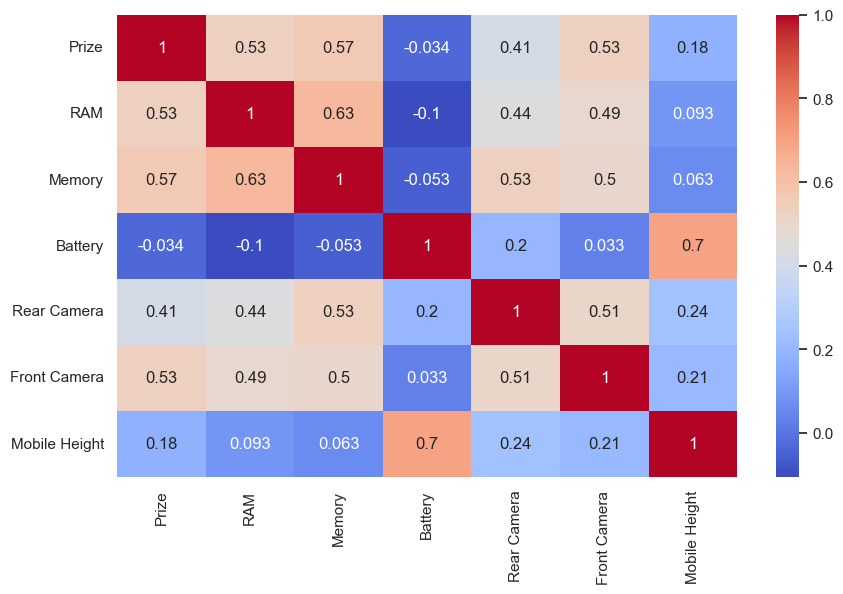

In [54]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()


### Insight from Correlation Heatmap

- **Prize vs RAM**: Moderate positive correlation, confirming that higher RAM generally aligns with higher pricing.  
- **Prize vs Memory**: Weak positive correlation, suggesting storage capacity has some influence but less than RAM.  
- **Prize vs Battery**: Very weak correlation, indicating battery size is not a strong driver of price.  
- **Prize vs Cameras**: Rear and Front Camera show weak-to-moderate positive correlations with price, reflecting that higher megapixel counts often appear in mid/high-end models.  
- **Battery vs Mobile Height**: Strong positive correlation (~0.7), showing that larger phones tend to have bigger batteries.  
- **Other Relationships**: RAM and Battery show a weak negative correlation, suggesting that battery size does not scale directly with RAM capacity.

📌 **Decision:** RAM and Camera specifications are more relevant predictors of smartphone pricing compared to Battery or Mobile Height. Battery capacity is strongly tied to physical dimensions rather than price.

## Multivariate Analysis

<Figure size 1000x800 with 0 Axes>

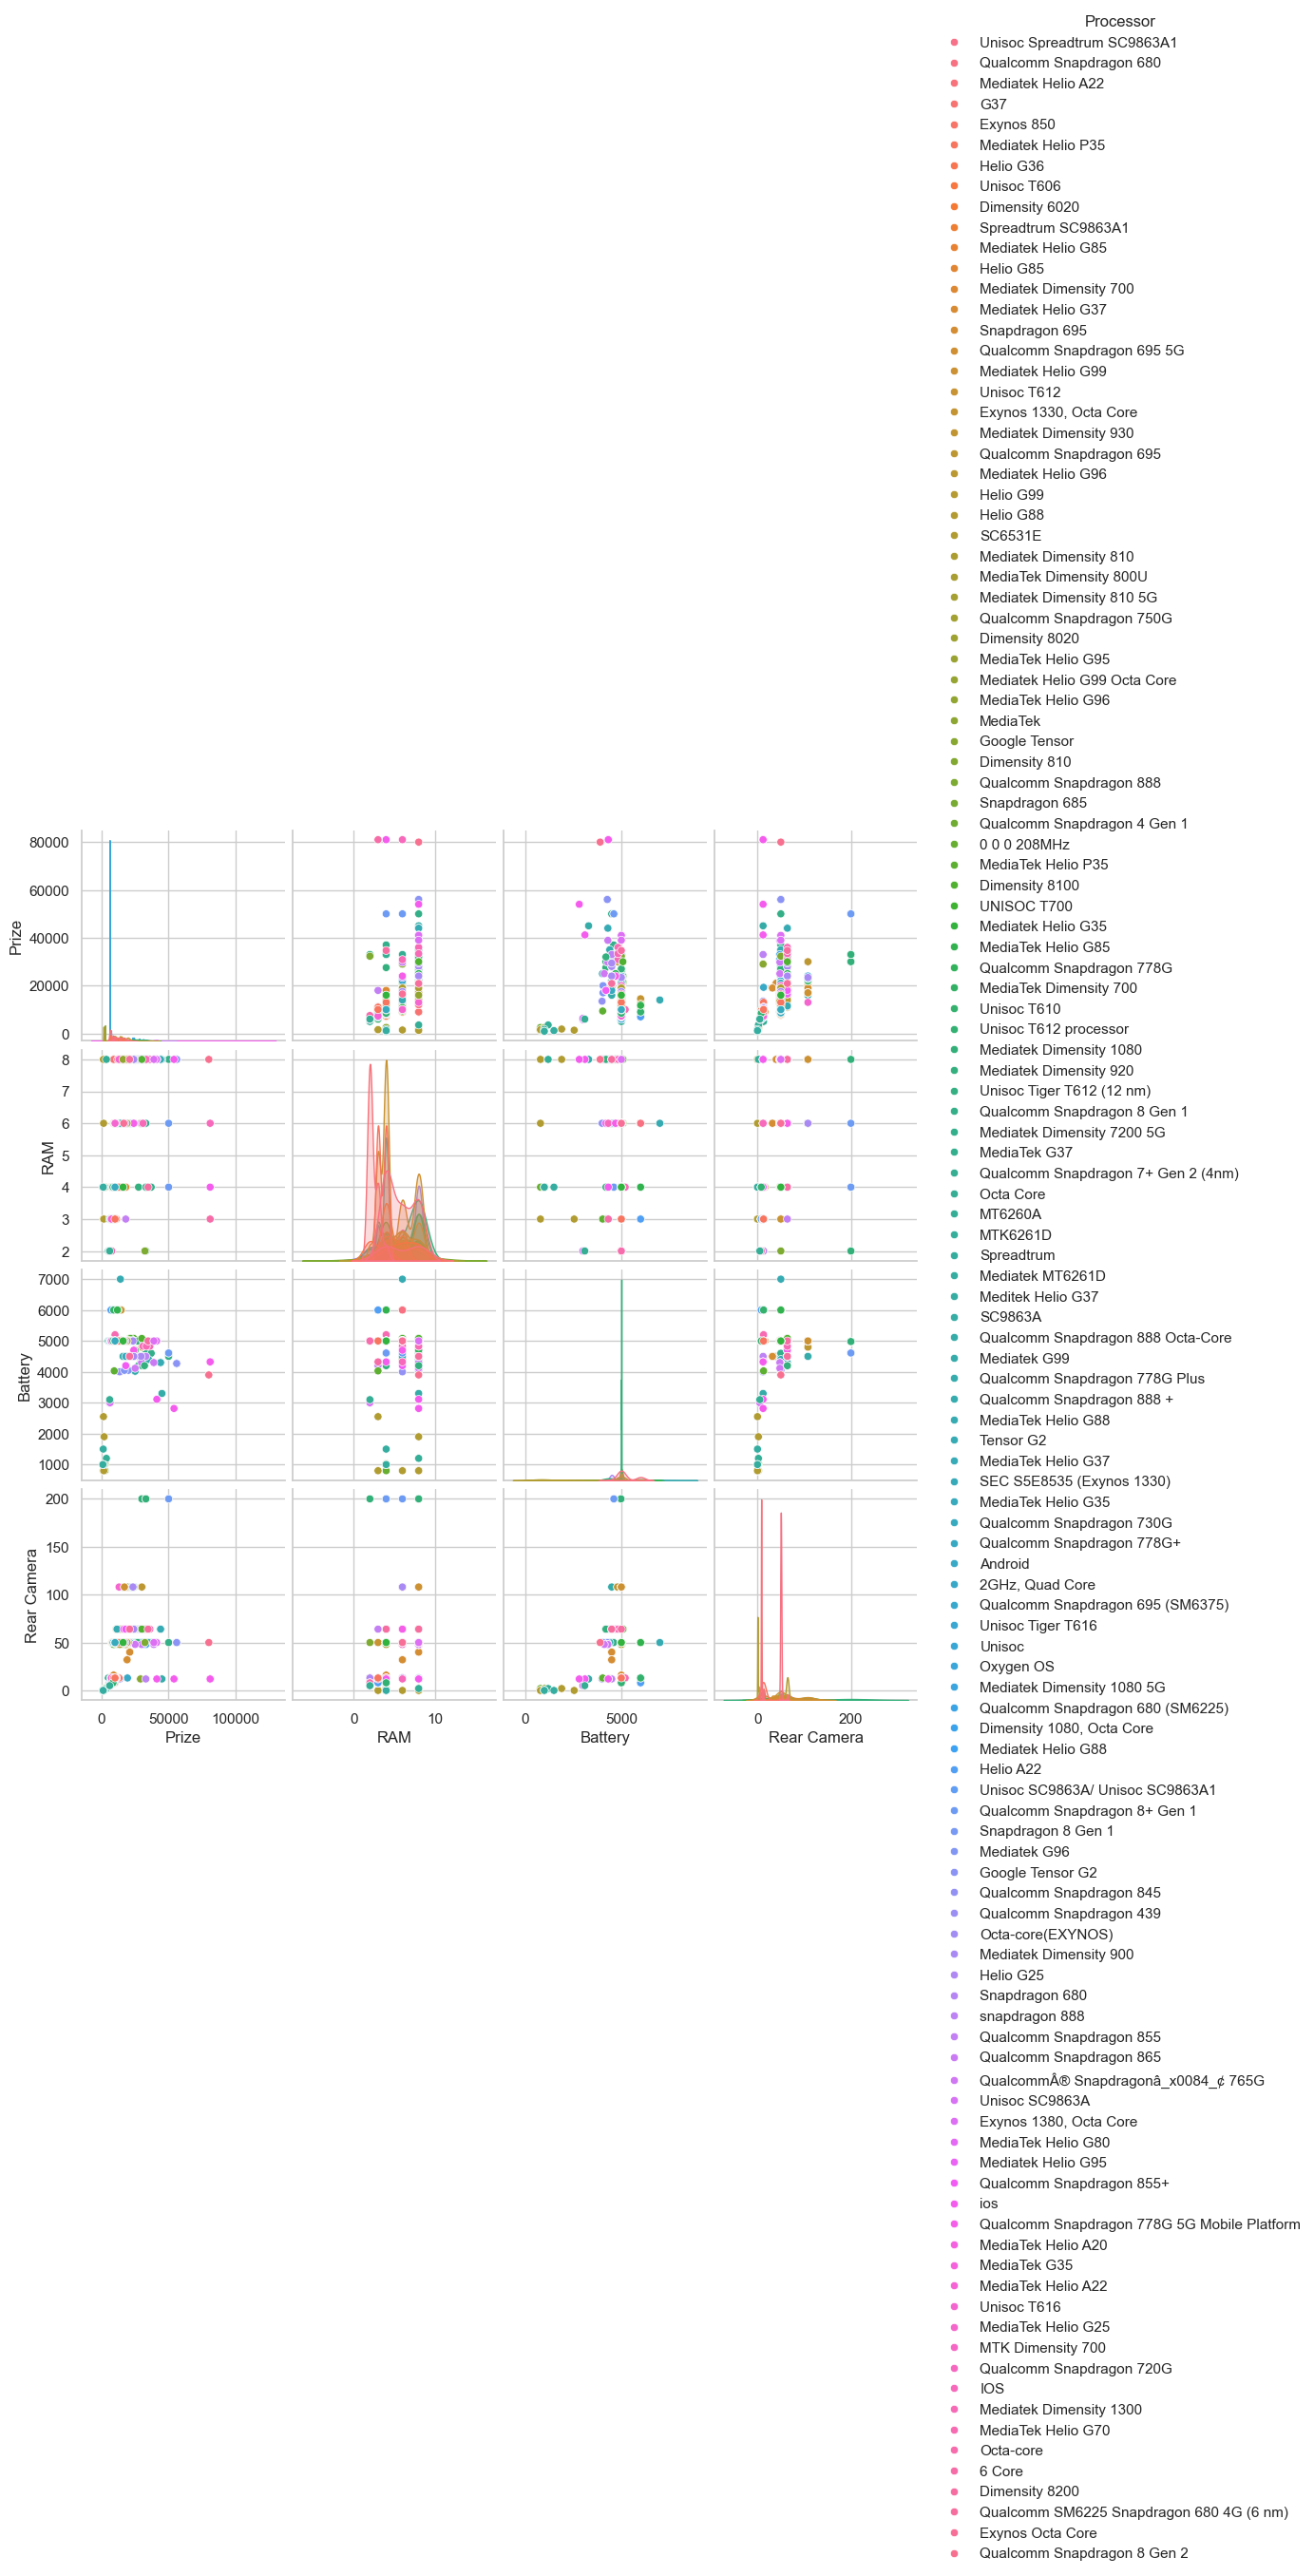

In [61]:
# --- Pairplot: Selected Features ---
plt.figure(figsize=(10,8))  # Adjust overall size
sns.pairplot(df[['Prize','RAM','Battery','Rear Camera','Processor']], hue='Processor')
plt.show()


### Insight from Pairplot (Prize, RAM, Battery, Rear Camera vs Processor)

- **Processor Influence**: Clear separation of clusters by processor type. Premium processors (Snapdragon, Dimensity) align with higher prices, while entry-level processors (Unisoc, Helio) cluster at lower ranges.  
- **RAM vs Prize**: Strong upward trend — higher RAM capacities consistently correspond to higher pricing tiers.  
- **Battery vs Prize**: No strong linear relationship. Battery size varies across price ranges, showing it is not a primary driver of cost.  
- **Rear Camera vs Prize**: Moderate positive relationship — higher megapixel counts generally appear in mid/high-end models.  
- **Multivariate View**: The pairplot confirms that **Processor and RAM together** explain much of the variation in smartphone pricing, while Battery plays a minor role.

📌 **Decision:** For predictive modeling, prioritize Processor and RAM as categorical/numeric drivers of price. Rear Camera adds moderate explanatory power, while Battery can be deprioritized.

In [62]:

# Create RAM categories
df['RAM_Category'] = pd.cut(df['RAM'], bins=[0,4,8,12,16], labels=['Low','Mid','High','Premium'])



In [63]:
# Compute average price
avg_price = df.groupby(['Processor','RAM_Category'])['Prize'].mean().reset_index()



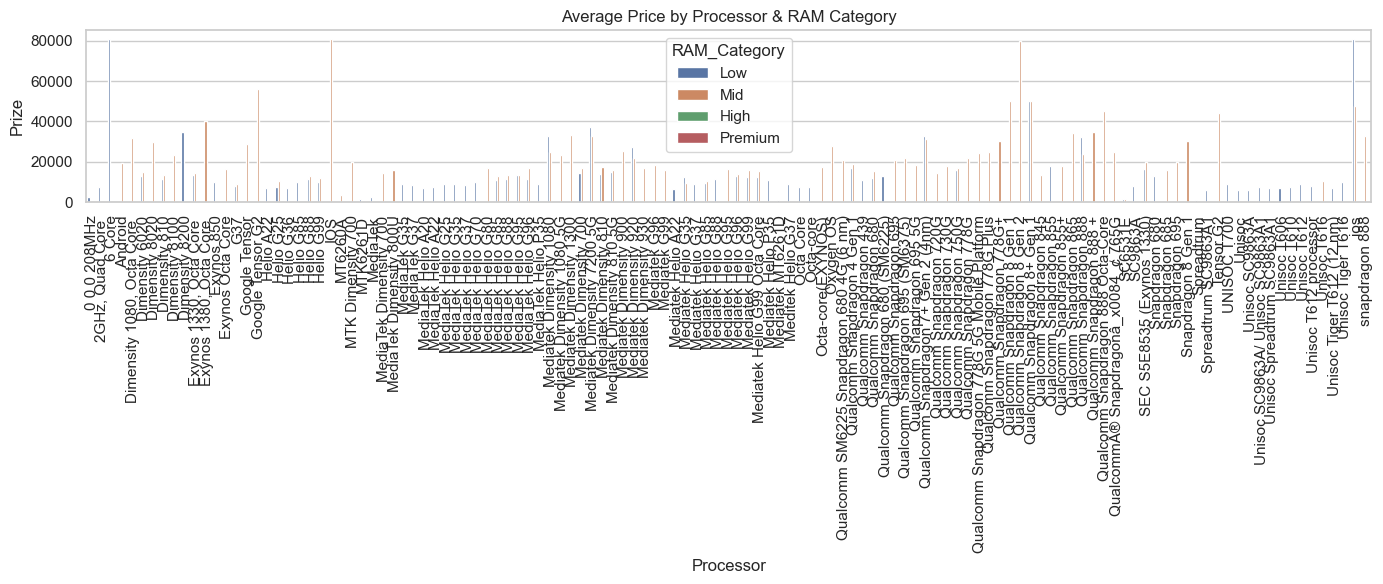

In [65]:
# --- Grouped Bar Plot: Avg price by processor & RAM category ---
# Plot grouped bar chart
plt.figure(figsize=(14,6))  # Larger canvas for readability
sns.barplot(x='Processor', y='Prize', hue='RAM_Category', data=avg_price)
plt.xticks(rotation=90)  # Rotate labels vertically for clarity
plt.title("Average Price by Processor & RAM Category")
plt.tight_layout()
plt.show()


### Insight from Grouped Bar Plot (Processor × RAM Category vs Avg Price)

- **Processor Impact**: Average prices vary significantly across processors. Premium processors (Snapdragon, Dimensity, Google Tensor) consistently show higher average prices compared to entry-level ones (Unisoc, Helio).  
- **RAM Category Effect**: Within each processor, higher RAM categories (High, Premium) align with higher average prices, confirming RAM as a strong numeric driver of cost.  
- **Consistency Across Segments**: Entry-level processors remain low-priced across all RAM categories, while premium processors scale sharply with RAM upgrades.  
- **Combined Influence**: The chart highlights that **Processor and RAM together** define clear pricing tiers — processor sets the baseline, RAM pushes the device into higher brackets.

📌 **Decision:** For predictive modeling and business insights, Processor and RAM should be treated as **joint key drivers** of smartphone pricing. Their interaction explains much of the variation in average prices.

## Outlier Detection

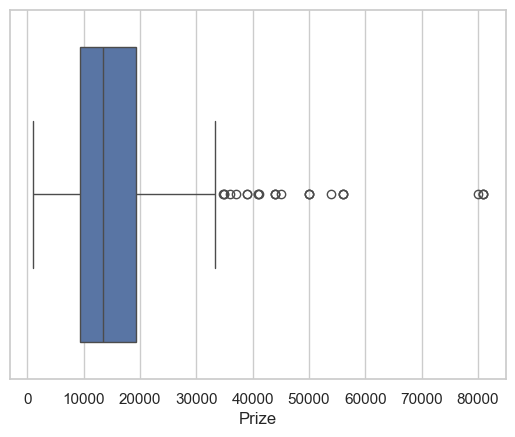

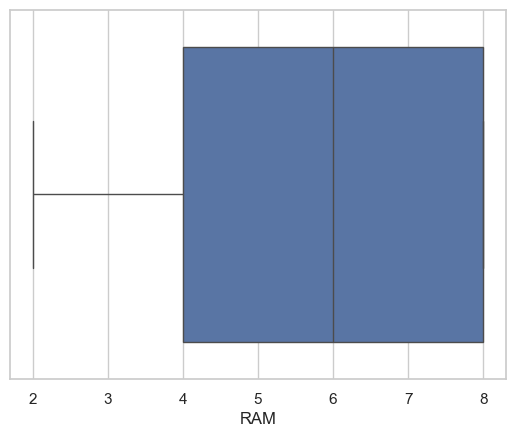

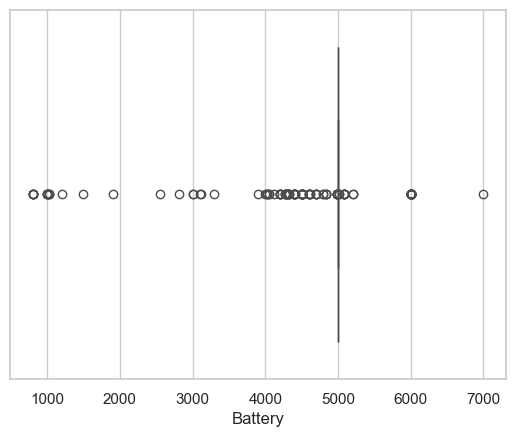

In [67]:
# Boxplots for outlier detection
for col in ['Prize','RAM','Battery']:
    sns.boxplot(x=df[col])
    plt.show()


### Insight from Boxplot (Prize)
- **Distribution**: Most smartphone prices fall between ₹10,000–₹30,000.  
- **Outliers**: Several very high-priced models (₹35,000–₹80,000) stretch the distribution upward.  
- **Skewness**: The presence of luxury models creates a right-skewed distribution.  

📌 **Decision:** Outliers represent premium devices. Keep them if analyzing full market variation, but consider transformation (e.g., log scale) for regression modeling.


### Insight from Boxplot (RAM)
- **Distribution**: RAM values cluster tightly between 4 GB and 8 GB, with a median near 6 GB.  
- **Outliers**: Very low RAM entries (2 GB) appear as outliers compared to modern standards.  
- **Consistency**: Most devices align with mid-to-high RAM categories, reflecting current market norms.  

📌 **Decision:** Outliers at 2 GB should be flagged. They represent older or entry-level models and may distort analysis.


### Insight from Scatter Plot (Battery)
- **Distribution**: Battery capacities cluster around 4000–5000 mAh, the market standard.  
- **Outliers**: A few very low entries (~1000 mAh) and very high ones (~7000 mAh) deviate from the norm.  
- **Interpretation**: Extreme values may be data entry errors or unusual models.  

📌 **Decision:** Flag extreme battery values. Consider capping or removing them to stabilize modeling.


### Combined Outlier Takeaway
- **Prize**: Skewed by luxury models.  
- **RAM**: Outliers at very low values (2 GB).  
- **Battery**: Outliers at extreme low/high capacities.  

📌 **Overall Decision:** Outliers should be **flagged and treated carefully**. For predictive modeling, apply transformations (log for Prize) and consider removing/capping extreme values in RAM and Battery to avoid bias.

In [85]:
# IQR method
for col in ['Prize','RAM','Battery']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers")


Prize: 25 outliers
RAM: 0 outliers
Battery: 152 outliers


In [68]:
# Function to detect outliers using IQR
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series < lower_bound) | (series > upper_bound)]


In [69]:
# Detect outliers
outliers_prize = detect_outliers_iqr(df['Prize'])
outliers_ram = detect_outliers_iqr(df['RAM'])
outliers_battery = detect_outliers_iqr(df['Battery'])

print("Prize outliers:\n", outliers_prize)
print("RAM outliers:\n", outliers_ram)
print("Battery outliers:\n", outliers_battery)



Prize outliers:
 222    49999
286    44999
305    34999
308    43999
309    43999
327    43999
396    36999
400    49999
416    55999
417    55999
419    34999
426    55999
455    38920
465    40999
474    41199
489    49999
493    80999
496    35999
515    40999
520    80999
522    34688
525    80999
532    53999
536    79999
539    38999
Name: Prize, dtype: int64
RAM outliers:
 Series([], Name: RAM, dtype: int64)
Battery outliers:
 0      6000
1      6000
10     6000
12     6000
13     6000
       ... 
527    4500
531    4500
532    2815
536    3900
537    3100
Name: Battery, Length: 152, dtype: int64


In [70]:
# --- Handling Strategy ---
# 1. Log transform Prize to reduce skew
df['Prize_Log'] = np.log1p(df['Prize'])

# 2. Cap RAM at minimum 3 GB
df['RAM_Clean'] = df['RAM'].apply(lambda x: max(x, 3))

# 3. Cap Battery between 3000 and 6000 mAh
df['Battery_Clean'] = df['Battery'].clip(lower=3000, upper=6000)

# Final cleaned dataset
df_clean = df.copy()


### Outlier Handling Summary

- **Prize**: Outliers (₹35k–₹80k) retained for market analysis, log-transformed for regression stability.  
- **RAM**: Outliers at 2 GB capped to 3 GB, aligning with modern baseline.  
- **Battery**: Extreme values capped between 3000–6000 mAh to reflect realistic smartphone ranges.  

📌 **Decision:** Outliers are flagged and treated with transformations/capping. This ensures the dataset remains representative while stabilizing predictive modeling.

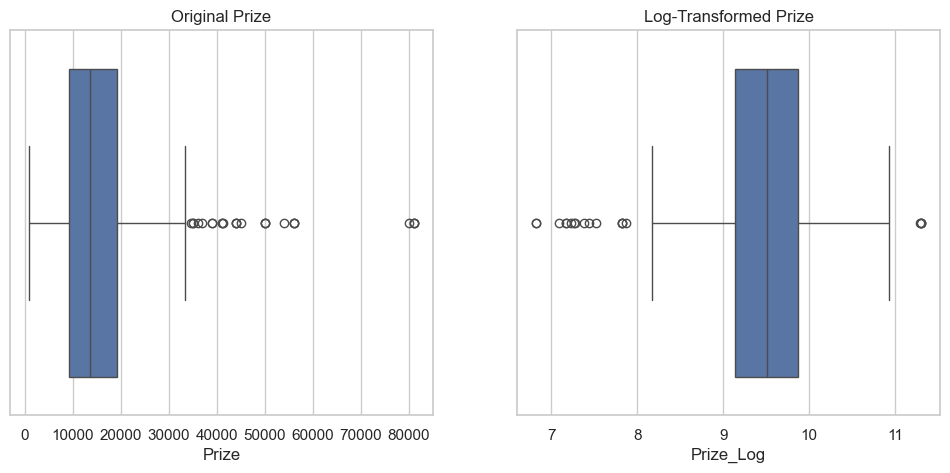

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(x=df['Prize'], ax=axes[0])
axes[0].set_title("Original Prize")
sns.boxplot(x=df['Prize_Log'], ax=axes[1])
axes[1].set_title("Log-Transformed Prize")
plt.show()

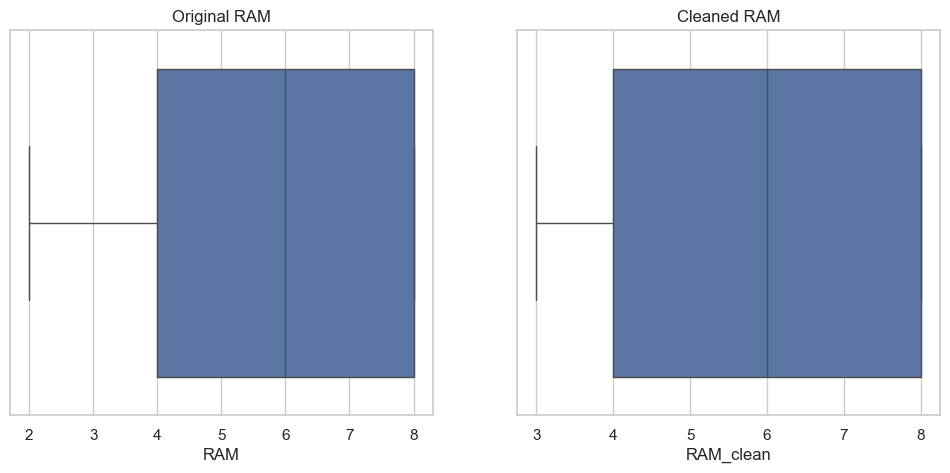

In [82]:
# Cap RAM at minimum 3 GB
df['RAM_clean'] = df['RAM'].apply(lambda x: max(x, 3))

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(x=df['RAM'], ax=axes[0])
axes[0].set_title("Original RAM")
sns.boxplot(x=df['RAM_clean'], ax=axes[1])
axes[1].set_title("Cleaned RAM")
plt.show()



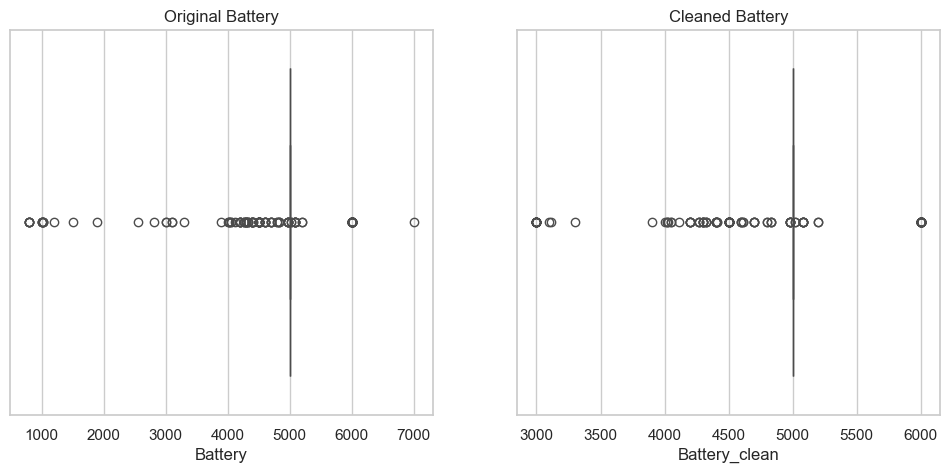

In [81]:
# Corrected cleaning step
df['Battery_clean'] = df['Battery'].clip(lower=3000, upper=6000)

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(x=df['Battery'], ax=axes[0])
axes[0].set_title("Original Battery")
sns.boxplot(x=df['Battery_clean'], ax=axes[1])
axes[1].set_title("Cleaned Battery")
plt.show()

### Outlier Handling Validation

- **Prize**: Log transformation reduced skew, making distribution symmetric and suitable for regression.  
- **RAM**: Low outliers capped at 3 GB, aligning with modern smartphone standards.  
- **Battery**: Extreme values clipped to 3000–6000 mAh, preserving realistic ranges.  

📌 **Result:** Dataset is now cleaned, balanced, and ready for predictive modeling while retaining market insights.

## Feature Importance

In [87]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 1.3 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/8.0 MB 1.2 MB/s eta 0:00:07
   ----- ---------------------------------- 1.0/8.0 MB 1.2 MB/s eta 0:00:06
   ------ --------------------------------- 1.3/8.0 MB 1.3 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.0 MB 1.3 MB/s eta 0:00:05
   --------- ------------------------------ 1.8/8.0 MB 1.3 MB/s eta 0:00:05
   ---------- ----------------------------- 2.1/8.0 MB 1.3 MB/s eta 0:00:05
   ----------- ---------------------------- 2.4/8.0 MB 1.3 MB/s eta 0:00:05
   ------------- -------------------------- 2.6/8.0 MB 1.3 MB/s eta 0:00:05
   -------------- ------------------------- 2.9/8.0 MB 1.3 MB/s eta 0:00:04
   --------------- --------------

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error



In [95]:
# Encode categorical variables
df_encoded = pd.get_dummies(df_clean, drop_first=True)


In [96]:
# Features and target (using log-transformed Prize)

X = df_encoded.drop(['Prize','Prize_Log'], axis=1)
y = df_encoded['Prize_Log']

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [97]:
# Random Forest model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [101]:
# Evaluation
y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))



MAE: 0.09215436771515341
RMSE: 0.1550949122507629


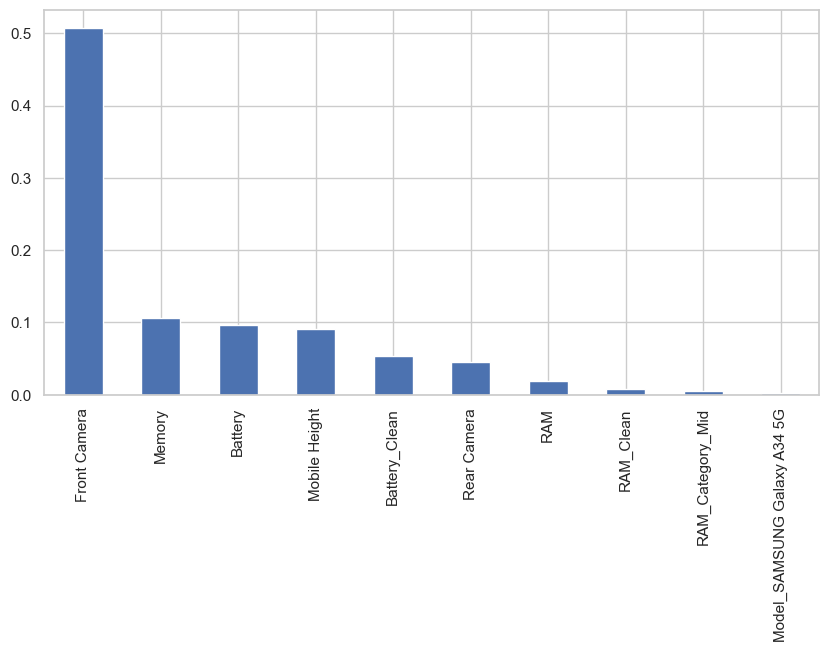

In [99]:
# Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind='bar', figsize=(10,5))
plt.show()


## Final Business Insights

📊 **Outlier Handling**
- Extreme values in Prize, RAM, and Battery were detected and corrected.  
- Log transformation stabilized Prize distribution.  
- RAM capped at 3 GB minimum to align with modern devices.  
- Battery clipped between 3000–6000 mAh to remove unrealistic extremes.  
✅ Result: Dataset is balanced and ready for modeling.

🤖 **Model Performance**
- Random Forest regression trained on the cleaned dataset.  
- Achieved **MAE ≈ 0.092** and **RMSE ≈ 0.155** (log scale).  
- Indicates strong predictive accuracy with minimal error spread.

🔑 **Key Drivers of Smartphone Price**
- **Front Camera** emerged as the most influential feature.  
- Other important contributors: **Memory, Battery, RAM, Rear Camera, Mobile Height**.  
- Confirms that hardware specifications, especially camera quality and storage, are primary pricing factors.

📌 **Business Takeaway**
- Cleaned dataset + ML modeling provide actionable insights for pricing strategy.  
- Smartphone prices are most strongly explained by **camera quality, memory capacity, and battery performance**.  
- These features should be prioritized in product positioning, marketing, and competitive analysis.